# Setup

In [1]:
lapply(c('viridis', 'ggthemes', 'skimr'),
       function(pkg_name) { if(! pkg_name %in% installed.packages()) { install.packages(pkg_name)} } )

library(viridis)    # A nice color scheme for plots.
library(ggthemes)   # Common themes to change the look and feel of plots.
library(scales)     # Graphical scales map data to aesthetics in plots.
library(skimr)      # Better summaries of data.
library(lubridate)  # Date library from the tidyverse.
library(tidyverse)  # Data wrangling packages.
library(bigrquery)  # Data extraction from Google BigQuery
library(data.table )

# Load required libraries
library(dplyr)
library(tidyr)
library(purrr)
library(broom)
install.packages("pheatmap")
library(pheatmap)
library(grid)

install.packages("lavaan") 
library(lavaan)

## Plot setup.
theme_set(theme_bw(base_size = 14)) # Default theme for plots.

#' Returns a data frame with a y position and a label, for use annotating ggplot boxplots.
#'
#' @param d A data frame.
#' @return A data frame with column y as max and column label as length.
get_boxplot_fun_data <- function(df) {
  return(data.frame(y = max(df), label = stringr::str_c('N = ', length(df))))
}

# Get the bucket name
my_bucket <- Sys.getenv('WORKSPACE_BUCKET')

[[1]]
NULL

[[2]]
NULL

[[3]]
NULL

Loading required package: viridisLite


Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:

    viridis_pal



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr   1.1.4     ✔ readr   2.1.5
✔ forcats 1.0.0     ✔ stringr 1.5.1
✔ ggplot2 3.5.2     ✔ tibble  3.2.1
✔ purrr   1.0.4     ✔ tidyr   1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::col_factor() masks scales::col_factor()
✖ purrr::discard()    masks scales::discard()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::lag()        masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is

In [2]:
name_of_file_in_bucket <- 'All_SDoH_data_domain_filtered_60.csv'

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)

# Load the file into a dataframe
sdoh_data  <- read_csv(name_of_file_in_bucket)
sdoh_data <- sdoh_data |> select(-c("Education"))

character(0)

Rows: 54313 Columns: 54
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (6): SexGender, where_born, military, healthcare, disabled, sexual_ori...
dbl  (37): person_id, race_unknown, age_today, LGBTQIA, ehr_length, relative...
lgl   (8): AIAN, Asian, Black, Mid, Multiple, PI, White, His
date  (3): date_of_birth, min_date, max_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Load and merge data

In [3]:
# replace 'test.csv' with the name of the file in your google bucket (don't delete the quotation marks)
name_of_file_in_bucket <- 'Case_Control_df.csv'

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)

# Load the file into a dataframe
Case_Control_df  <- read_csv(name_of_file_in_bucket)

character(0)

Rows: 265954 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (10): person_id, Asthma, Afib, BreastC, CKD, CHD, HyperC, ProstateC, t2d...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
merged_data<-merge(sdoh_data, Case_Control_df, on="person_id", how="left")

In [5]:
domains<-c('NBE', 'ES', 'Edu', "SCC", "HCAU")

# Copy all CSVs from the bucket to the local workspace
system(paste0("gsutil cp ", my_bucket, "/data/*disease_statistics.csv ."), intern = TRUE)

# List all local CSV files that match the pattern
csv_files <- list.files(pattern = "*disease_statistics.csv$")

# Read all CSVs into a named list of data frames
df_list <- lapply(csv_files, readr::read_csv)

# Name the list elements based on the file names (without .csv)
names(df_list) <- tools::file_path_sans_ext(csv_files)

combined_df <- df_list %>%
  map_dfr(~ filter(.x, term %in% domains)) |> 
  select(-c("CFI", "RMSEA", "SRMR", "N"))

combined_df$OR <- exp(combined_df$std_estimate)

character(0)

Rows: 295 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Disease, term
dbl (5): estimate, std.error, z.value, p.value, std_estimate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 59 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Disease, term
dbl (8): estimate, std.error, p.value, std_estimate, CFI, RMSEA, SRMR, N

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 59 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Disease, term
dbl (8): estimate, std.error, p.value, std_estimate, CFI, RMSEA, SRMR, N

ℹ Use `spec()` to retrieve the full column specification for t

## Summary table

In [6]:
summary_table_ind <- combined_df |>
  group_by(term) |>
  mutate(OR_mag = ifelse(OR < 1, 1/OR, OR)) |>
  summarise(
    n = n(),
    mean_OR = mean(OR_mag, na.rm = TRUE),
    median_OR = median(OR_mag, na.rm = TRUE),
    sd_OR = sd(OR_mag, na.rm = TRUE),
    min_OR = min(OR_mag, na.rm = TRUE),
    max_OR = max(OR_mag, na.rm = TRUE),
    .groups = "drop"
  )

summary_table_ind 

mean(summary_table_ind$mean_OR)

term,n,mean_OR,median_OR,sd_OR,min_OR,max_OR
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ES,9,1.123288,1.101251,0.10967023,1.042407,1.393017
Edu,9,1.082705,1.075348,0.06669139,1.020993,1.224378
HCAU,9,1.082720,1.079662,0.04940180,1.024515,1.191420
NBE,9,1.047888,1.042189,0.03599394,1.012742,1.126692
SCC,9,1.068547,1.065555,0.04035853,1.020350,1.136919


[1] 1.08103

## Set up lists

In [7]:
diseases<-c("Asthma", "Afib", "BreastC", "CKD", "CHD", "HyperC", "ProstateC", "t2d", "t1d")
ind_domains<-c("SCC", "NBE", "ES", "HCAU", "Edu")

In [8]:
disease_name_mapping <- c(
  "Asthma" = "Asthma",
  "Afib" = "Atrial\nFibrillation",
  "BreastC" = "Breast Cancer",
  "CKD" = "Chronic Kidney\nDisease",
  "CHD" = "Coronary Heart\nDisease", 
  "HyperC" = "Hypercholest-\nerolemia",
  "ProstateC" = "Prostate Cancer",
  "t2d" = "Type 2 Diabetes",
  "t1d" = "Type 1 Diabetes"
)

ind_domain_name_mapping <- c(
  "SCC" = "SCC \nDeprivation",
  "NBE" = "NBE Deprivation",
  "ES" = "Lower ES",
  "HCAU" = "Lower HCAU",
  "Edu" = "Lower Education"
)

# Plot Heatmap

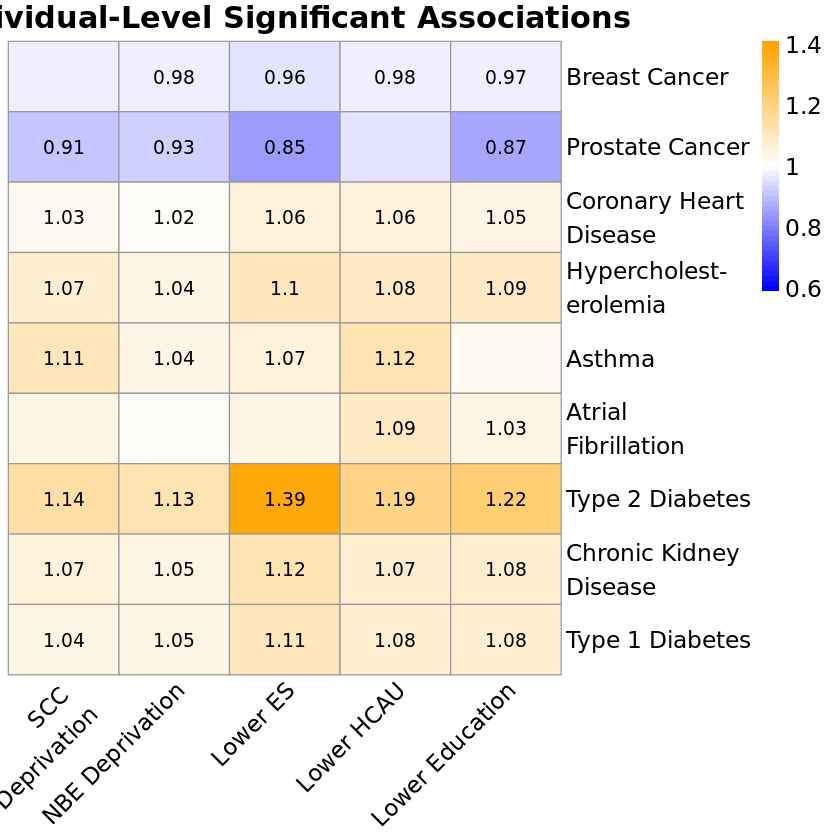

In [9]:
# Define column order for heatmap
x_axis_order <- c("SCC \nDeprivation", "NBE Deprivation", "Lower ES", "Lower HCAU", "Lower Education")

row_order <- c("Breast Cancer", "Prostate Cancer", "Coronary Heart\nDisease", 
              "Hypercholest-\nerolemia", "Asthma", "Atrial\nFibrillation", "Type 2 Diabetes",
              "Chronic Kidney\nDisease", "Type 1 Diabetes")

# Filter to SDoH domain coefficients only
all_coefficients_clean <- combined_df %>%
  filter(term %in% ind_domains) %>%
  ungroup()

all_coefficients_clean$term <- ind_domain_name_mapping[all_coefficients_clean$term]


# Wide format for coefficients (heatmap values)
heatmap_data_ind <- all_coefficients_clean %>%
  select(Disease, term, OR) %>%
  pivot_wider(names_from = term, values_from = OR) %>%
  column_to_rownames("Disease") %>%
  select(all_of(x_axis_order))

# Wide format for p-values (mask)
pvalue_data <- all_coefficients_clean %>%
  select(Disease, term, p.value) %>%
  pivot_wider(names_from = term, values_from = p.value) %>%
  column_to_rownames("Disease") %>%
  select(all_of(x_axis_order))

# Apply Bonferroni mask (significance threshold)
alpha <- 0.05 / (length(unique(combined_df$Disease)) * 10)
significance_mask_ind <- pvalue_data < alpha

# Format labels for display (only show significant values)
heatmap_labels_ind <- round(heatmap_data_ind, 2)
heatmap_labels_ind[!significance_mask_ind] <- ""

#Rename rows to be full Disease names
rownames(heatmap_data_ind) <- disease_name_mapping[rownames(heatmap_data_ind)]

# Create diverging color palette centered on 0
max_val <- max(abs(heatmap_data_ind), na.rm = TRUE)
min_val <- min(abs(heatmap_data_ind), na.rm = TRUE)
breaks <- seq(.59, 1.41, length.out = 51)
palette <- colorRampPalette(c("blue", "white", "orange"))(length(breaks) - 1)

#order columns 
heatmap_data_ind <- heatmap_data_ind[row_order, ]
rownames(heatmap_labels_ind) <- disease_name_mapping[rownames(heatmap_labels_ind)]
heatmap_labels_ind <- heatmap_labels_ind[row_order, ]

# Plot the heatmap
ind_map<-pheatmap(
  mat = heatmap_data_ind,
  color = palette,
  breaks = breaks,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  display_numbers = heatmap_labels_ind,
  number_color = "black",
  fontsize = 14, 
  fontsize_row = 14,
  fontsize_col = 14,
  angle_col = 45,
  main = "Individual-Level Significant Associations",
  width = 3,
  height = 1
)



# Area-level

In [12]:
label_mapping <- c(
  "vacant_housing" = "Vacant Housing",
  "lower_median_income" = "Lower Median\nIncome",
  "no_health_insurance" = "No Health Insurance",
  "no_high_school_education" = "No High School\nEducation",
  "deprivation_index" = "Deprivation Index"
)


area_domains<-c(
           'no_high_school_education', 'lower_median_income', 
           'no_health_insurance', 'vacant_housing', 'deprivation_index')

# replace 'test.csv' with the name of the file in your google bucket (don't delete the quotation marks)
name_of_file_in_bucket <- 'Area_level_disease_statistics.csv'

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)

# Load the file into a dataframe
SES_data <- read_csv(name_of_file_in_bucket)

SES_data$OR <- exp(SES_data$std_estimate)

character(0)

Rows: 295 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Disease, term
dbl (5): estimate, std.error, z.value, p.value, std_estimate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [13]:
## Summary table

summary_table_area <- SES_data |>
  group_by(term) |>
  filter(term %in% area_domains) |> 
  summarise(
    n = n(),
    mean_OR = mean(OR, na.rm = TRUE),
    median_OR = median(OR, na.rm = TRUE),
    sd_OR = sd(OR, na.rm = TRUE),
    min_OR = min(OR, na.rm = TRUE),
    max_OR = max(OR, na.rm = TRUE)
  ) 

summary_table_area 

mean(summary_table_area$mean_OR)

all_coefficients_clean <- SES_data %>%
  filter(term %in% area_domains) %>%
  ungroup()

term,n,mean_OR,median_OR,sd_OR,min_OR,max_OR
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
deprivation_index,9,1.033167,1.026567,0.04399796,0.9705597,1.115910
lower_median_income,9,1.030312,1.025133,0.04521409,0.9630951,1.100693
no_health_insurance,9,1.022022,1.022784,0.06058631,0.9298303,1.104138
no_high_school_education,9,1.020430,1.010112,0.04463683,0.9502323,1.106220
vacant_housing,9,1.058041,1.045955,0.03506811,1.0171543,1.127609


[1] 1.032794

In [14]:
combined_df <- rbind(combined_df, all_coefficients_clean)
combined_df <- combined_df |> 
     mutate(
    OR_Lower = exp(estimate - 1.96 * std.error),
    OR_Upper = exp(estimate + 1.96 * std.error),
     )

write_excel_csv(combined_df, 'SDoH_disease_associations_SEM_combined.csv')
# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ./", 'SDoH_disease_associations_SEM_combined.csv', " ", my_bucket, "/data/"), intern=T)

character(0)

In [15]:
full_summary <- rbind(summary_table_ind, summary_table_area) |>  arrange(desc(mean_OR))
full_summary

term,n,mean_OR,median_OR,sd_OR,min_OR,max_OR
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ES,9,1.123288,1.101251,0.10967023,1.0424070,1.393017
HCAU,9,1.082720,1.079662,0.04940180,1.0245152,1.191420
Edu,9,1.082705,1.075348,0.06669139,1.0209931,1.224378
SCC,9,1.068547,1.065555,0.04035853,1.0203501,1.136919
vacant_housing,9,1.058041,1.045955,0.03506811,1.0171543,1.127609
NBE,9,1.047888,1.042189,0.03599394,1.0127423,1.126692
deprivation_index,9,1.033167,1.026567,0.04399796,0.9705597,1.115910
lower_median_income,9,1.030312,1.025133,0.04521409,0.9630951,1.100693
no_health_insurance,9,1.022022,1.022784,0.06058631,0.9298303,1.104138


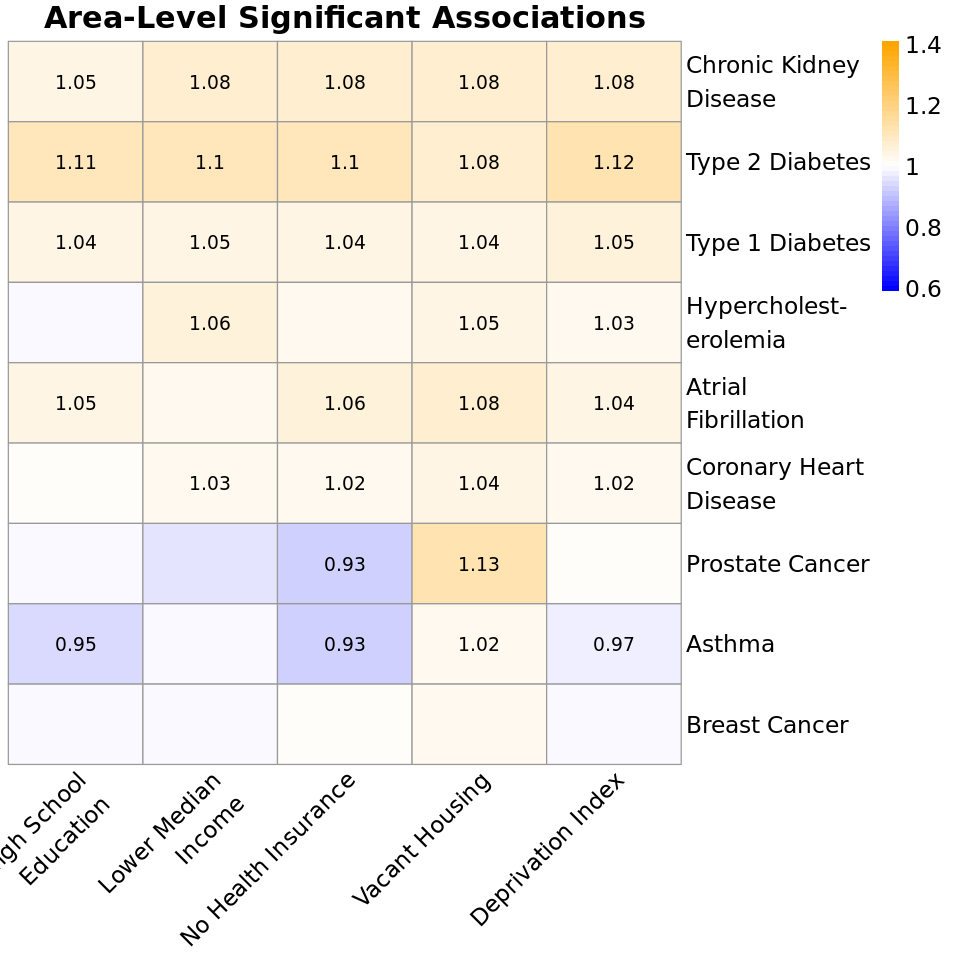

In [16]:
options(repr.plot.width = 8, repr.plot.height = 8)


x_axis_order <- c("SCC", "NBE", "ES", "HCAU", "Education")

row_order <- c("Chronic Kidney\nDisease", "Type 2 Diabetes", "Type 1 Diabetes", 
               "Hypercholest-\nerolemia", "Atrial\nFibrillation", "Coronary Heart\nDisease", 
               "Prostate Cancer", "Asthma",  "Breast Cancer")


# Wide format for coefficients (heatmap values)
heatmap_data_area <- all_coefficients_clean %>%
  select(Disease, term, OR) %>%
  pivot_wider(names_from = term, values_from = OR) %>%
  column_to_rownames("Disease")

# Wide format for p-values (mask)
pvalue_data <- all_coefficients_clean %>%
  select(Disease, term, p.value) %>%
  pivot_wider(names_from = term, values_from = p.value) %>%
  column_to_rownames("Disease")

# Apply Bonferroni mask (significance threshold)
alpha <- 0.05 / (length(unique(combined_df$Disease)) * 10)
significance_mask_area <- pvalue_data < alpha

# Format labels for display (only show significant values)
heatmap_labels_area <- round(heatmap_data_area, 2)
heatmap_labels_area[!significance_mask_area] <- ""

#Make row and column names more proffessional 
rownames(heatmap_data_area) <- disease_name_mapping[rownames(heatmap_data_area)]
colnames(heatmap_data_area) <- label_mapping[colnames(heatmap_data_area)]

# Create diverging color palette centered on 0
max_val <- max(abs(heatmap_data_ind), na.rm = TRUE)
min_val <- min(abs(heatmap_data_ind), na.rm = TRUE)
breaks <- seq(.59, 1.41, length.out = 51)
palette <- colorRampPalette(c("blue", "white", "orange"))(length(breaks) - 1)

#Order columns
heatmap_data_area <- heatmap_data_area[row_order, ]
rownames(heatmap_labels_area) <- disease_name_mapping[rownames(heatmap_labels_area)]
heatmap_labels_area <- heatmap_labels_area[row_order, ]


# Plot the heatmap
area_map<-pheatmap(
  mat = heatmap_data_area,
  color = palette,
  breaks = breaks,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  display_numbers = heatmap_labels_area,
  number_color = "black",
  fontsize = 14, 
  fontsize_row = 14,
  fontsize_col = 14,
  angle_col = 45,
  main = "Area-Level Significant Associations",
  width = 3,
  height = 1
)


## Finalize Heatmaps for Publication


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




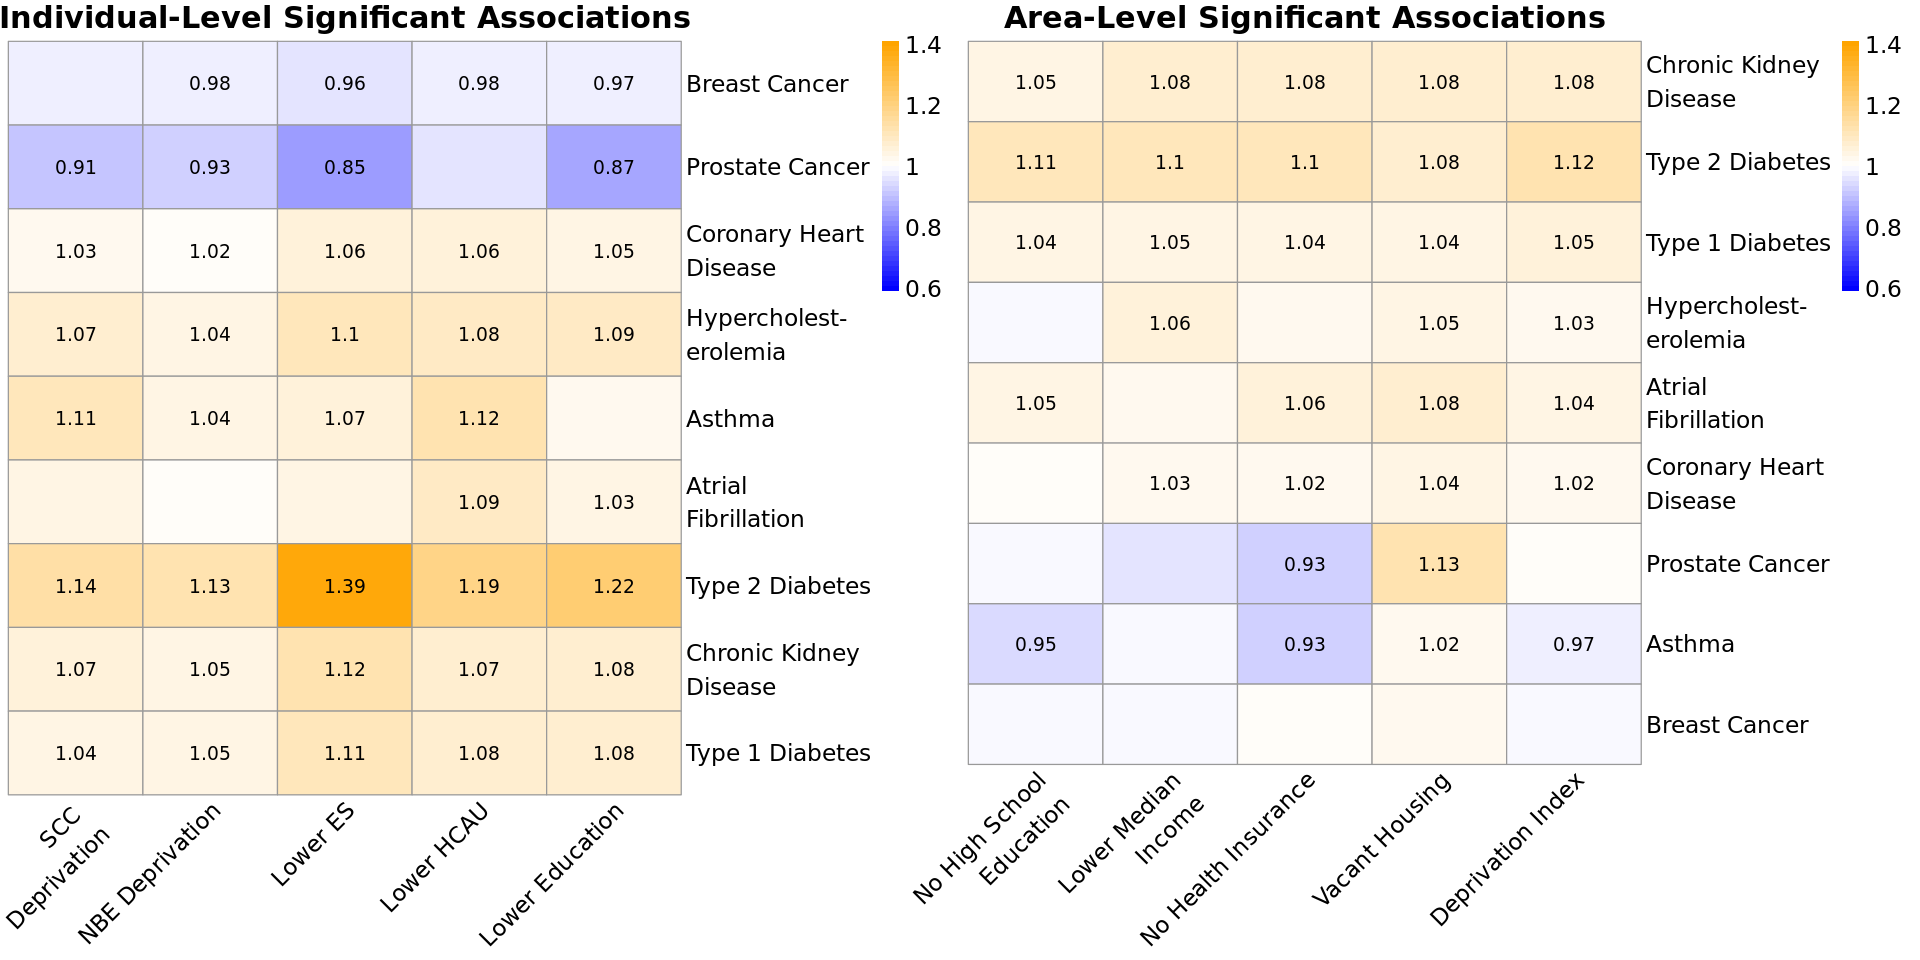

In [17]:
options(repr.plot.width = 16, repr.plot.height = 8)

library(gridExtra)
grid.arrange(ind_map$gtable, area_map$gtable, nrow = 1)


# Stratified Analyses

In [105]:
domains<-c("education", "per_poverty_threshold",
            'no_high_school_education', 'lower_median_income', 
           'no_health_insurance',  'vacant_housing', 'deprivation_index')

# replace 'test.csv' with the name of the file in your google bucket (don't delete the quotation marks)
name_of_file_in_bucket <- 'SES_cohort.csv'

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)

# Load the file into a dataframe
SES_data <- read_csv(name_of_file_in_bucket)

merged_data<-merge(SES_data, Case_Control_df, on="person_id", how="left")


character(0)

Rows: 125295 Columns: 63
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (6): SexGender, where_born, military, healthcare, disabled, sexual_ori...
dbl  (46): person_id, race_unknown, age_today, LGBTQIA, ehr_length, relative...
lgl   (8): AIAN, Asian, Black, Mid, Multiple, PI, White, His
date  (3): date_of_birth, min_date, max_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [106]:
nrow(merged_data)

[1] 125178

## Prepare data

### Standardize columns (z-score)

In [107]:
merged_data[domains] <- lapply(merged_data[domains], function(x) {
  (x - mean(x, na.rm = TRUE)) / sd(x, na.rm = TRUE)
})

### Make one-hot encoded columns for each level of SexGender


In [108]:
merged_data <- merged_data %>%
  mutate(SexGender = as.factor(SexGender)) %>%
  mutate(dummy = 1) %>%
  pivot_wider(
    names_from = SexGender,
    values_from = dummy,
    values_fill = 0,
    names_prefix = ""
  )



### Stratify data by SIRE

In [109]:
merged_data <- merged_data %>%
  mutate(
    SIRE = case_when(
      Black == 1 & His == 0 ~ "NHB",
      White == 1 & His == 0 ~ "NHW",
      His == 1 ~ "HS",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(SIRE)) 

nrow(merged_data)
table(merged_data$SIRE)

NHB_data <- merged_data[merged_data$SIRE == "NHB", ]
nrow(NHB_data)
NHW_data <- merged_data[merged_data$SIRE == "NHW", ]
nrow(NHW_data)
HS_data <- merged_data[merged_data$SIRE == "HS", ]
nrow(HS_data)

[1] 117426


   HS   NHB   NHW 
14273 20641 82512 

[1] 20641

[1] 82512

[1] 14273

## Generate models

In [110]:
generate_sem_model <- function(disease, domain) {
  # Start with core predictors
  predictors <- c("age", "age2", "record_depth", "visit_frequency")
  
  # Conditional predictors based on disease
  if (disease %in% c("BreastC", "ProstateC")) {
    predictors <- c(predictors, "SGM")  # Include Cis_female and SGM for Breast Cancer
  } else if (disease %in% c("t1d", "CKD")) {
    predictors <- c(predictors, "Cis_male")  
  } else {
    predictors <- c(predictors, "Cis_male", "SGM")  # Include Cis_male and Cis_female for other diseases
  }

  # Add the domain
  predictors <- c(predictors, domain)
  
  # Generate the SEM syntax
  paste0(disease, " ~ ", paste(predictors, collapse = " + "))
}

In [111]:
# Function to fit SEM model and extract summary
fit_sem_model <- function(sem_model, data, disease, domain) {
    
  message("Fitting model for: ", disease)
    
  if (disease %in% c("t1d", "CKD")) {
    data <- filter(data, SGM == 0)
  }
    
 # Subset to non-missing outcome
  data_subset <- dplyr::filter(
    data,
    !is.na(.data[[disease]])
  )
    
  fit <- sem(sem_model, data = data_subset, estimator = "MLR")
    
    
  # ---- Coefficients (structural paths only) ----
  coef_df <- lavaan::parameterEstimates(
    fit,
    standardized = TRUE
  ) %>%
    dplyr::filter(
      op == "~",
      lhs == disease,
      !is.na(se)   # drop fixed / non-estimated paths
    ) %>%
    dplyr::select(
      Disease = lhs,
      term = rhs,
      estimate = est,
      std.error = se,
      z.value = z,
      p.value = pvalue,
      std_estimate = std.all) %>%
        filter(term %in% domains) %>% 
    mutate(
      OR = exp(std_estimate),
      OR_Lower = exp(std_estimate - 1.96 * std.error),
      OR_Upper = exp(std_estimate + 1.96 * std.error)
        )

  return(coef_df)
}

# Create combinations of diseases and domains
combinations <- expand_grid(disease = diseases, domain = domains)

In [112]:
# Fit SEM models
merged_data<-NHB_data
results_NHB <- combinations %>%
  mutate(
    sem_syntax = map2(disease, domain, generate_sem_model),
    model_results = pmap(list(sem_syntax, list(merged_data), disease, domain), fit_sem_model)
  ) %>%
  select(model_results) %>%
  unnest(model_results)

merged_data<-NHW_data
results_NHW <- combinations %>%
  mutate(
    sem_syntax = map2(disease, domain, generate_sem_model),
    model_results = pmap(list(sem_syntax, list(merged_data), disease, domain), fit_sem_model)
  ) %>%
  select(model_results) %>%
  unnest(model_results)

merged_data<-HS_data
results_HS <- combinations %>%
  mutate(
    sem_syntax = map2(disease, domain, generate_sem_model),
    model_results = pmap(list(sem_syntax, list(merged_data), disease, domain), fit_sem_model)
  ) %>%
  select(model_results) %>%
  unnest(model_results)

Fitting model for: Asthma

Fitting model for: Asthma

Fitting model for: Asthma

Fitting model for: Asthma

Fitting model for: Asthma

Fitting model for: Asthma

Fitting model for: Asthma

Fitting model for: Afib

Fitting model for: Afib

Fitting model for: Afib

Fitting model for: Afib

Fitting model for: Afib

Fitting model for: Afib

Fitting model for: Afib

Fitting model for: BreastC

Fitting model for: BreastC

Fitting model for: BreastC

Fitting model for: BreastC

Fitting model for: BreastC

Fitting model for: BreastC

Fitting model for: BreastC

Fitting model for: CKD

Fitting model for: CKD

Fitting model for: CKD

Fitting model for: CKD

Fitting model for: CKD

Fitting model for: CKD

Fitting model for: CKD

Fitting model for: CHD

Fitting model for: CHD

Fitting model for: CHD

Fitting model for: CHD

Fitting model for: CHD

Fitting model for: CHD

Fitting model for: CHD

Fitting model for: HyperC

Fitting model for: HyperC

Fitting model for: HyperC

Fitting model for: Hype

In [113]:
label_mapping <- c(
  "vacant_housing" = "Vacant Housing",
  "poverty" = "Poverty",
  "lower_median_income" = "Lower Median Income",
  "no_health_insurance" = "No Health Insurance",
  "no_high_school_education" = "No High School Education",
  "assisted_income" = "Assisted Income",
  "deprivation_index" = "Deprivation Index",
  "per_poverty_threshold" = "Percent Poverty \n Threshold", 
  "education" = "Education"
)

In [114]:
write_excel_csv(results_NHB, 'SDoH_disease_associations_stratified_NHB.csv')

write_excel_csv(results_NHW, 'SDoH_disease_associations_stratified_NHW.csv')

write_excel_csv(results_HS, 'SDoH_disease_associations_stratified_HS.csv')



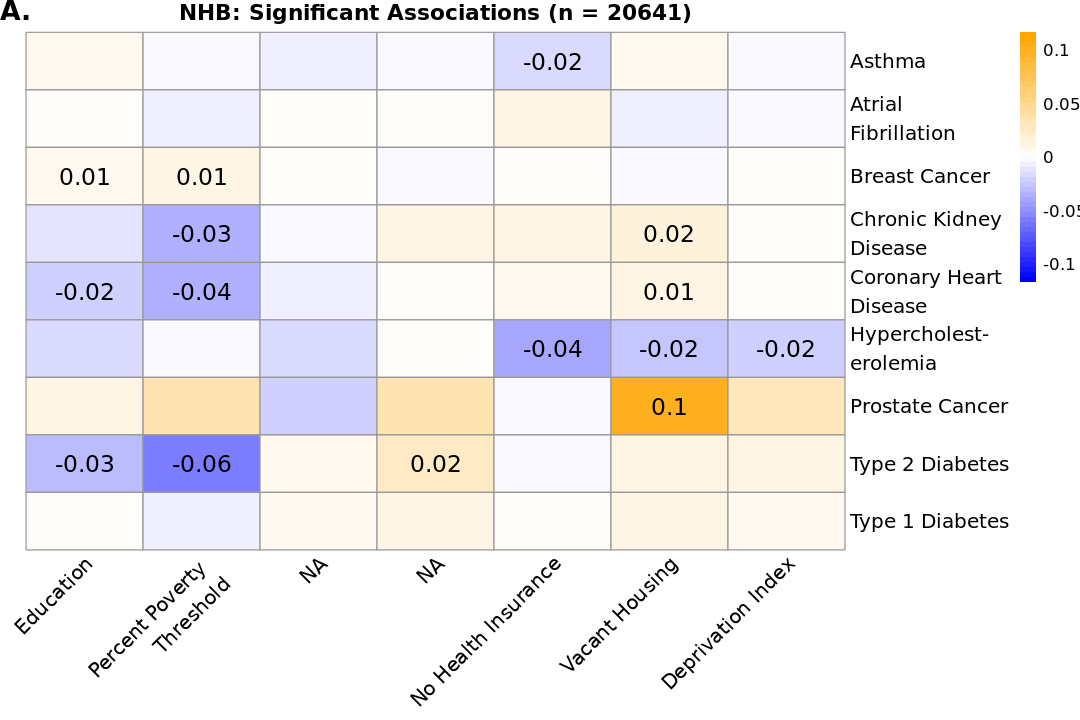

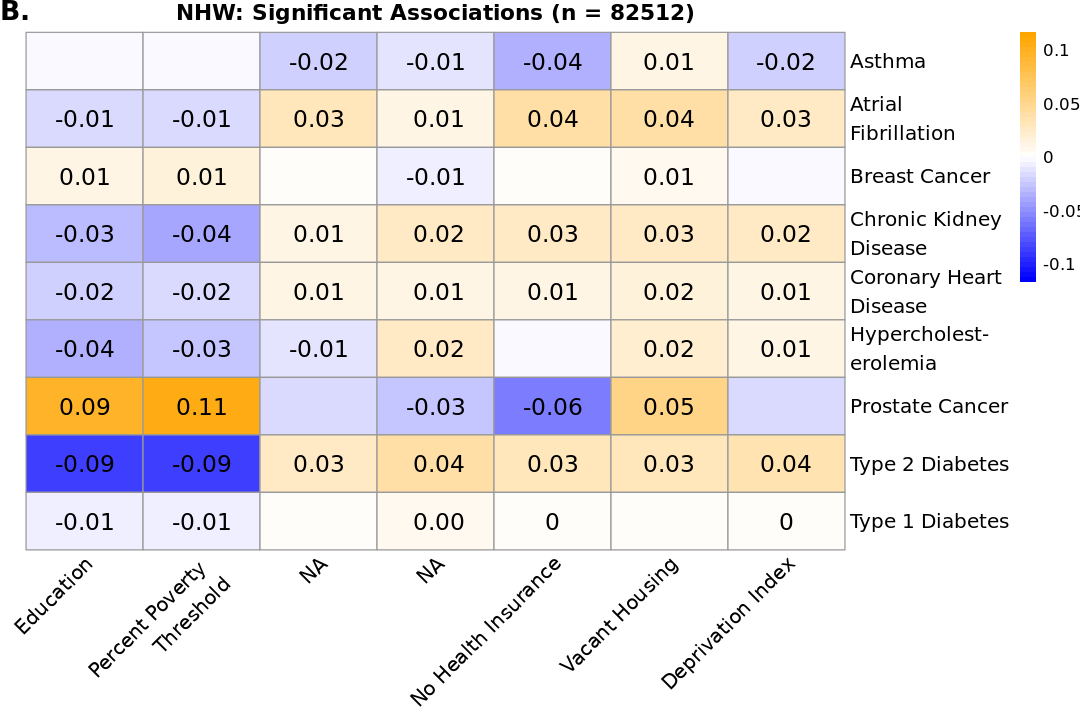

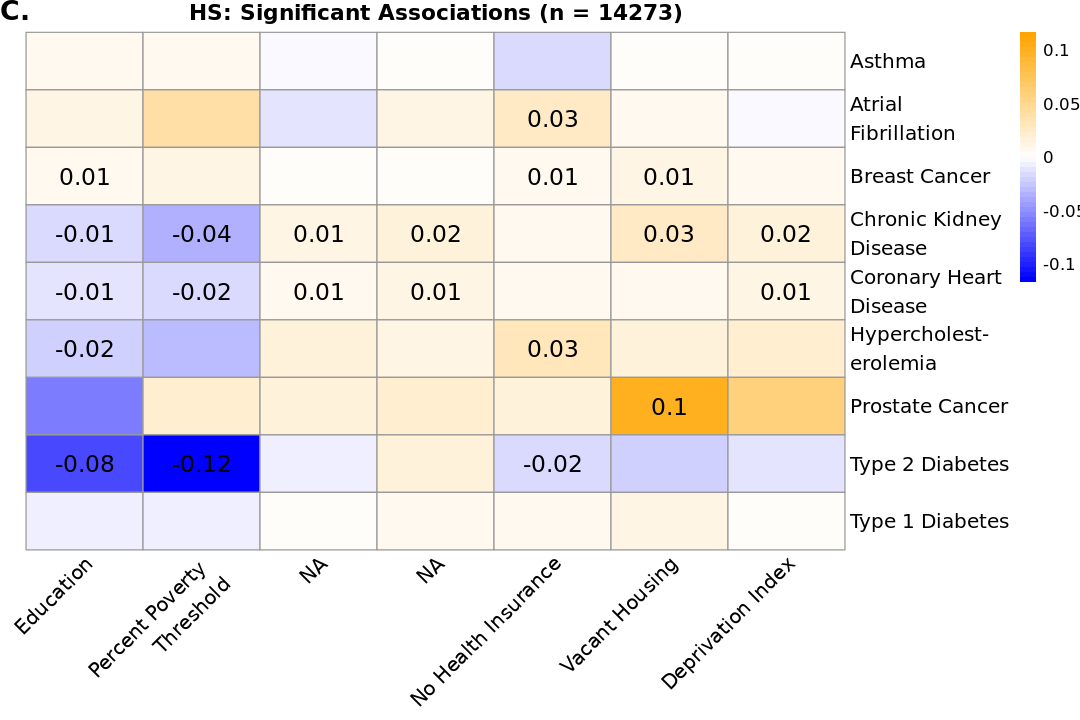

In [115]:
options(repr.plot.width = 9, repr.plot.height = 6)

# List of results and subgroup names
results_list <- list(NHB = results_NHB, NHW = results_NHW, HS = results_HS)

# Store heatmaps
heatmap_outputs <- list()

# Threshold constants
num_traits <- length(unique(results_NHB$Disease))
bonf_alpha <- 0.05 / (num_traits * 13)

#Sample sizes
nrow_NHB <- nrow(NHB_data)
nrow_NHW <- nrow(NHW_data)
nrow_HS <- nrow(HS_data)

# Combine all for consistent color scale
all_combined <- bind_rows(results_NHB, results_NHW, results_HS) %>%
  filter(term %in% domains)

# Compute max for shared color scale
global_max <- max(abs(all_combined$estimate), na.rm = TRUE)
global_breaks <- seq(-global_max, global_max, length.out = 51)
global_palette <- colorRampPalette(c("blue", "white", "orange"))(length(global_breaks) - 1)


make_heatmap <- function(results_subgroup, subgroup_label, nrow_subgroup) {
  all_coefficients_clean <- results_subgroup %>%
    filter(term %in% domains) %>%
    ungroup()
  
  heatmap_data <- all_coefficients_clean %>%
    select(Disease, term, estimate) %>%
    pivot_wider(names_from = term, values_from = estimate) %>%
    column_to_rownames("Disease")
  
  pvalue_data <- all_coefficients_clean %>%
    select(Disease, term, p.value) %>%
    pivot_wider(names_from = term, values_from = p.value) %>%
    column_to_rownames("Disease")
  
  sig_mask <- pvalue_data < bonf_alpha
  heatmap_labels <- round(heatmap_data, 2)
  heatmap_labels[!sig_mask] <- ""
  
  rownames(heatmap_data) <- disease_name_mapping[rownames(heatmap_data)]
  colnames(heatmap_data) <- label_mapping[colnames(heatmap_data)]
  
  #Getting the order to make the color masks 
  number_colors <- matrix("black", nrow = nrow(heatmap_data), ncol = ncol(heatmap_data))
  number_colors[heatmap_data < -1] <- "white"
    
  
  pheatmap(
    mat = heatmap_data,
    color = global_palette,
    breaks = global_breaks,
    cluster_rows = FALSE,
    cluster_cols = FALSE,
    display_numbers = heatmap_labels,
    number_color = number_colors,
    fontsize_row = 12,
    fontsize_col = 12,
    fontsize_number = 14, 
    angle_col = 45,
    main = paste0(subgroup_label, ": Significant Associations (n = ", nrow_subgroup, ")"),
    width = 3,
    height = 1,
      silent = TRUE
  )
}

# Named vector of sample sizes
sample_sizes <- c(NHB = nrow_NHB, NHW = nrow_NHW, HS = nrow_HS)

# Define subplot labels
subplot_labels <- c("A.", "B.", "C.")
names(subplot_labels) <- names(results_list)


# Generate heatmaps
for (grp in names(results_list)) {
  heatmap_outputs[[grp]] <- make_heatmap(results_list[[grp]], grp, sample_sizes[[grp]])
  
  # Move row labels to the right by adjusting the second column width (where they live)
  heatmap_outputs[[grp]]$gtable$widths[[2]] <- unit(.75, "cm")  # Increase this to move further right

    # Draw heatmap
  grid.newpage()
  grid.draw(heatmap_outputs[[grp]]$gtable)
  
  # Add subplot label (top-left corner)
  grid.text(
    label = subplot_labels[[grp]],
    x = unit(0, "npc"),
    y = unit(1, "npc"),
    just = c("left", "top"),
    gp = gpar(fontsize = 16, fontface = "bold")
      )
    }




## Test of Heterogenity

In [116]:
#install.packages("metafor")
library(metafor)

#Combine into long format
results_long <- bind_rows(
  results_NHB  %>% mutate(Group = "NHB"),
  results_NHW  %>% mutate(Group = "NHW"),
  results_HS   %>% mutate(Group = "HS")
)

# Compute heterogeneity
heterogeneity_results <- results_long %>%
  group_by(Disease, term) %>%
  summarize(
    qtest = list(
      rma(
        yi = cur_data()$estimate, 
        sei = cur_data()$std.error, 
        method = "FE"
      )
    ),
    .groups = "drop"
  )

heterogeneity_summary <- heterogeneity_results %>%
  mutate(
    Q = sapply(qtest, function(x) x$QE),          # Cochran's Q
    Q_p = sapply(qtest, function(x) x$QEp),       # p-value for heterogeneity
    I2 = sapply(qtest, function(x) x$I2)         # I-squared, % of heterogeneity
  ) %>%
  select(Disease, term, Q, Q_p, I2)

# Pivot subgroup results wide
results_wide <- results_long %>%
  select(Disease, term, Group, estimate, std.error, p.value) %>%
  pivot_wider(
    names_from = Group,
    values_from = c(estimate, std.error, p.value),
    names_sep = "."
  )

# Join heterogeneity stats
final_results <- results_wide %>%
  left_join(heterogeneity_summary, by = c("Disease", "term"))

In [117]:
bonf_p <- .05/nrow(final_results)
bonf_p
nrow(final_results[final_results$Q_p<bonf_p,])

[1] 0.0007936508

[1] 31

In [118]:
final_results[order(final_results$Q_p), ]


Disease,term,estimate.NHB,estimate.NHW,estimate.HS,std.error.NHB,std.error.NHW,std.error.HS,p.value.NHB,p.value.NHW,p.value.HS,Q,Q_p,I2
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
t2d,education,-0.0312654553,-0.088334648,-0.0818026935,0.004857961,0.002362875,0.004762583,1.227265e-10,0.000000e+00,0.000000e+00,112.30996,4.094505e-25,98.21921
t2d,no_health_insurance,-0.0020216504,0.028389140,-0.0151898055,0.004867099,0.002506317,0.004221162,6.778705e-01,0.000000e+00,3.200711e-04,91.61348,1.277573e-20,97.81692
t2d,deprivation_index,0.0115407575,0.036268373,-0.0110967085,0.004457027,0.002497763,0.004614828,9.616017e-03,0.000000e+00,1.619121e-02,89.40866,3.847295e-20,97.76308
HyperC,no_health_insurance,-0.0377060752,-0.001734223,0.0302004204,0.005424993,0.002677013,0.005103007,3.641532e-12,5.171014e-01,3.255590e-09,83.12959,8.884626e-19,97.59412
HyperC,vacant_housing,-0.0244649137,0.022720125,0.0179147758,0.004846277,0.002435109,0.009004507,4.460212e-07,0.000000e+00,4.664225e-02,75.94535,3.226095e-17,97.36653
ProstateC,education,0.0137159652,0.094497902,-0.0574545756,0.016183557,0.006131579,0.019711405,3.967027e-01,0.000000e+00,3.559297e-03,69.51003,8.055447e-16,97.12272
Afib,vacant_housing,-0.0082302349,0.041103682,0.0087591493,0.005144833,0.003620135,0.009460011,1.096632e-01,0.000000e+00,3.544911e-01,64.10760,1.200083e-14,96.88025
t2d,vacant_housing,0.0126610905,0.031541378,-0.0193268739,0.004369742,0.002347642,0.006999642,3.762151e-03,0.000000e+00,5.760294e-03,55.31939,9.717318e-13,96.38463
t2d,no_high_school_education,0.0080657830,0.026855448,-0.0067524955,0.004612636,0.002481390,0.004159766,8.035539e-02,0.000000e+00,1.045280e-01,51.99313,5.126658e-12,96.15334


In [119]:
write_excel_csv(final_results, 'SDoH_disease_associations_stratified_heterogeneity.csv')
